# ArcMatch perturbation scale probe

Controlled perturbation of freefold cotrain GT chunks, scored with the **same** `arcmatch_metrics` the baseline / ARC runs use (`M=32`, `lever=0.1`, `dt=1/30`).

**Hypothesis:** baseline and ARC share the scorer; any scale bias comes from the prediction path (baseline deinterp to 45 vs ARC tokenize→detokenize to horizon 100) before that scorer.

Two scoring modes:
1. **Direct** — perturb deinterp GT, call `arcmatch_metrics` (metric purity).
2. **Evaluator-faithful** — push the perturbed full chunk through the baseline or ARC pred pipeline, then score vs deinterp GT.


In [20]:
from __future__ import annotations

import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R

# Find repo root (directory that contains egomimic/) from cwd or this file's parents.
def _find_repo() -> Path:
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "egomimic" / "eval" / "arc_metrics.py").is_file():
            return cand
    # fallback: notebook lives at egomimic/scripts/tutorials/
    return Path("../../..").resolve()

REPO = _find_repo()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from egomimic.eval.arc_metrics import (
    ARM_XYZ,
    XYZ_COLS,
    arcmatch_metrics,
    chunk_metrics,
    dtw_metrics,
)
from egomimic.eval.bimanual_cartesian_eval import BimanualCartesianEval
from egomimic.rldb.zarr.arc_length_tokenizer import TokenizeBimanualArcLengthCartesian

# --- knobs matching abc_fstshirt_mecka_freefold_cotrain_{baseline,arcD40M100} ---
ARCMATCH_POINTS = 32
ROT_LEVER_M = 0.1
METRIC_DT = 1.0 / 30.0
ARC_CHUNK_ROWS = 45
ACTION_HORIZON = 100
MIN_DISTANCE_UNIT = 0.40
RESAMPLED_VECTOR_LENGTH = 100
VELOCITY_MODE = "per_waypoint"
SCRATCH_DIR = Path("/coc/flash7/scratch/arc-training")
RNG = np.random.default_rng(420042)

deinterpolate = BimanualCartesianEval._deinterpolate

TOKENIZER = TokenizeBimanualArcLengthCartesian(
    action_key="actions_cartesian",
    output_action_key="actions_cartesian",
    min_distance_unit=MIN_DISTANCE_UNIT,
    resampled_vector_length=RESAMPLED_VECTOR_LENGTH,
    dt=METRIC_DT,
    preserve_action_key=None,
    velocity_mode=VELOCITY_MODE,
)

print("repo:", REPO)
print("tokenizer velocity_mode:", TOKENIZER.velocity_mode)


repo: /coc/flash7/acheluva3/EgoVerse-graph
tokenizer velocity_mode: per_waypoint


## Helpers: paths, perturbations, scoring

In [21]:
def make_path(
    n: int = 100,
    span: float = 0.6,
    *,
    wiggle: float = 0.05,
    ypr_span: float = 0.4,
    right_scale: float = 1.0,
    seed: int | None = None,
) -> np.ndarray:
    """Synthetic (T, 14) bimanual cartesian chunk (same layout as eval)."""
    t = np.linspace(0.0, 1.0, n)
    chunk = np.zeros((n, 14), dtype=np.float64)
    scales = (1.0, float(right_scale))
    for arm, (base, scale) in enumerate(zip((0, 7), scales)):
        chunk[:, base + 0] = t * span * scale
        chunk[:, base + 1] = wiggle * np.sin(2 * np.pi * t) * scale
        chunk[:, base + 2] = 0.02 * t * scale
        chunk[:, base + 3] = t * ypr_span * (1.0 if arm == 0 else 0.7)
        chunk[:, base + 6] = t
    if seed is not None:
        jitter = np.random.default_rng(seed).normal(0.0, 1e-4, size=chunk.shape)
        chunk[:, XYZ_COLS] += jitter[:, XYZ_COLS]
    return chunk


def make_synthetic_bank(n_per: int = 4) -> dict[str, list[np.ndarray]]:
    bank: dict[str, list[np.ndarray]] = {"synthetic": []}
    specs = [
        dict(n=100, span=0.6, right_scale=1.0),
        dict(n=100, span=0.8, right_scale=0.85),
        dict(n=200, span=0.7, wiggle=0.08, right_scale=1.1),
        dict(n=100, span=0.55, ypr_span=0.6, right_scale=0.9),
    ]
    for i in range(n_per):
        spec = specs[i % len(specs)]
        bank["synthetic"].append(make_path(**spec, seed=1000 + i))
    return bank


def perturb_xyz_translation(chunk: np.ndarray, delta_m: float) -> np.ndarray:
    out = chunk.copy()
    for cols in ARM_XYZ:
        out[:, cols[0]] += delta_m
    return out


def perturb_xyz_noise(chunk: np.ndarray, sigma_m: float, rng: np.random.Generator) -> np.ndarray:
    out = chunk.copy()
    noise = rng.normal(0.0, sigma_m, size=(len(chunk), len(XYZ_COLS)))
    out[:, XYZ_COLS] += noise
    return out


def perturb_ypr_noise(chunk: np.ndarray, theta_deg: float, rng: np.random.Generator) -> np.ndarray:
    """Left-multiply each arm YPR by a small random rotation of magnitude ~theta."""
    out = chunk.copy()
    if theta_deg <= 0:
        return out
    theta = math.radians(float(theta_deg))
    for ypr_cols in ((3, 4, 5), (10, 11, 12)):
        base = R.from_euler("ZYX", out[:, list(ypr_cols)])
        axes = rng.normal(size=(len(out), 3))
        axes /= np.linalg.norm(axes, axis=-1, keepdims=True).clip(min=1e-8)
        mags = rng.normal(loc=theta, scale=max(theta * 0.15, 1e-9), size=len(out)).clip(min=0.0)
        delta = R.from_rotvec(axes * mags[:, None])
        out[:, list(ypr_cols)] = (delta * base).as_euler("ZYX")
    return out


def perturb_truncate(chunk: np.ndarray, fraction: float) -> np.ndarray:
    keep = max(2, int(round(len(chunk) * float(fraction))))
    return chunk[:keep].copy()


def perturb_time_warp(chunk: np.ndarray, stretch: float) -> np.ndarray:
    """Resample the trajectory in time (stretch>1 = slower / more rows)."""
    stretch = float(stretch)
    if abs(stretch - 1.0) < 1e-12:
        return chunk.copy()
    from scipy.spatial.transform import Slerp

    n = len(chunk)
    new_n = max(2, int(round(n * stretch)))
    src = np.linspace(0.0, 1.0, n)
    dst = np.linspace(0.0, 1.0, new_n)
    out = np.zeros((new_n, 14), dtype=np.float64)
    for cols in list(ARM_XYZ) + [(6,), (13,)]:
        for c in cols:
            out[:, c] = np.interp(dst, src, chunk[:, c])
    for ypr_cols in ((3, 4, 5), (10, 11, 12)):
        rots = R.from_euler("ZYX", chunk[:, list(ypr_cols)])
        slerp = Slerp(src, rots)
        out[:, list(ypr_cols)] = slerp(dst).as_euler("ZYX")
    return out


def score_pair(pred: np.ndarray, gt: np.ndarray) -> dict[str, float]:
    """Production arcmatch (+ chunk/dtw when row counts allow), run knobs."""
    values = arcmatch_metrics(
        [pred],
        [gt],
        num_points=ARCMATCH_POINTS,
        dt=METRIC_DT,
        lever_m=ROT_LEVER_M,
    )
    rows = min(len(pred), len(gt))
    if rows >= 2:
        # chunk_metrics expects a batch axis (B, T, 14), matching the evaluator.
        values.update(
            chunk_metrics(pred[None, :rows], gt[None, :rows], lever_m=ROT_LEVER_M)
        )
        values.update(dtw_metrics([pred], [gt], max_samples=1))
    return values


def deinterpolate_traj(chunk: np.ndarray, rows: int = ARC_CHUNK_ROWS) -> np.ndarray:
    """Deinterpolate a (T, 14) or (B, T, 14) chunk.

    ``BimanualCartesianEval._deinterpolate`` indexes with ``[..., i, :]``, which
    works for both ranks; keep this helper so notebook paths stay explicit.
    """
    arr = np.asarray(chunk, dtype=np.float64)
    if arr.ndim not in (2, 3):
        raise ValueError(f"expected (T,14) or (B,T,14), got {arr.shape}")
    return deinterpolate(arr, rows)


def to_gt(chunk: np.ndarray) -> np.ndarray:
    """Evaluator GT path: deinterpolate to raw window (arc_chunk_rows=45)."""
    return deinterpolate_traj(chunk, ARC_CHUNK_ROWS)


def baseline_pred_path(perturbed_full: np.ndarray) -> np.ndarray:
    """Baseline _arc_pred_time_indexed without normalizer: deinterp to 45."""
    return deinterpolate_traj(perturbed_full, ARC_CHUNK_ROWS)


def arc_pred_path(perturbed_full: np.ndarray) -> np.ndarray:
    """ARC _arc_pred_time_indexed: tokenize then detokenize to action_horizon."""
    token = TOKENIZER.transform(
        {"actions_cartesian": np.asarray(perturbed_full, dtype=np.float64)}
    )["actions_cartesian"]
    return TOKENIZER.detokenize(token, ACTION_HORIZON)


print("helpers ready")


helpers ready


## Load trajectories (synthetic + optional real freefold chunks)

In [22]:
def try_load_real_chunks(max_per_emb: int = 3) -> dict[str, list[np.ndarray]]:
    """Load a few baseline cartesian action chunks from scratch cache.

    Uses the same filters / transform lists as the freefold baseline cotrain
    data config. Returns {} if scratch / deps are unavailable.
    """
    if not SCRATCH_DIR.is_dir():
        print(f"scratch missing: {SCRATCH_DIR}")
        return {}
    try:
        import torch

        from egomimic.rldb.embodiment.human import Human
        from egomimic.rldb.embodiment.yam import Yam
        from egomimic.rldb.filters import DatasetFilter
        from egomimic.rldb.zarr.zarr_dataset_multi import (
            MultiDataset,
            S3EpisodeResolver,
        )
    except Exception as exc:
        print(f"real-data imports failed: {exc}")
        return {}

    builders = {
        "yam_bimanual": dict(
            image_hw=[480, 640],
            debug=max_per_emb,
            build_key_map=lambda: Yam.get_keymap(keymap_mode="cartesian"),
            build_transforms=lambda: Yam.get_transform_list(
                action_mode="cartesian",
                coord_frame="eef_frame",
                rotation_mode="euler",
            ),
            filter_lambda=(
                "lambda row: row['embodiment'] == 'yam_bimanual' and "
                "row['lab'] == 'abc' and "
                "row['task'] == 'fold and stack the t-shirts' and "
                "row['zarr_processed_path'] != '' and row['is_deleted'] == False"
            ),
        ),
        "human_bimanual": dict(
            image_hw=[360, 640],
            debug=max_per_emb,
            build_key_map=lambda: Human.get_keymap(keymap_mode="cartesian"),
            build_transforms=lambda: Human.get_transform_list(
                action_mode="cartesian_gripper_padded",
                coord_frame="eef_frame",
                rotation_mode="euler",
                stride=1,
            ),
            filter_lambda=(
                "lambda row: row['embodiment'] == 'human_bimanual' and "
                "row['lab'] == 'mecka' and row['task'] == 'fold_clothes' and "
                "row['zarr_processed_path'] != '' and row['is_deleted'] == False"
            ),
        ),
    }

    out: dict[str, list[np.ndarray]] = {}
    for name, spec in builders.items():
        try:
            resolver = S3EpisodeResolver(
                str(SCRATCH_DIR),
                key_map=spec["build_key_map"](),
                transform_list=spec["build_transforms"](),
                image_hw=spec["image_hw"],
                debug=spec["debug"],
            )
            ds = MultiDataset._from_resolver(
                resolver,
                filters=DatasetFilter(filter_lambdas=[spec["filter_lambda"]]),
                sync_from_s3=False,
                mode="valid",
                valid_ratio=0.2,
                bounds_check=False,
            )
            loader = torch.utils.data.DataLoader(ds, batch_size=1, shuffle=False)
            chunks: list[np.ndarray] = []
            for batch in loader:
                act = batch["actions_cartesian"]
                if hasattr(act, "numpy"):
                    act = act.numpy()
                act = np.asarray(act, dtype=np.float64)
                if act.ndim == 3:
                    act = act[0]
                if act.shape[-1] != 14 or len(act) < 2:
                    continue
                chunks.append(act)
                if len(chunks) >= max_per_emb:
                    break
            if chunks:
                out[name] = chunks
                print(f"loaded {len(chunks)} {name} chunks, shapes={[c.shape for c in chunks]}")
            else:
                print(f"no usable chunks for {name}")
        except Exception as exc:
            print(f"skip {name}: {type(exc).__name__}: {exc}")
    return out


# Synthetic bank first so an interrupt during real I/O still leaves usable TRAJECTORIES.
TRAJECTORIES: dict[str, list[np.ndarray]] = make_synthetic_bank(n_per=4)
for src, chunks in TRAJECTORIES.items():
    print(f"{src}: {len(chunks)} chunks")

# Optional real freefold chunks (yam / mecka). Set False to skip slow S3/DB loads.
LOAD_REAL = True
if LOAD_REAL:
    try:
        real = try_load_real_chunks(max_per_emb=3)
        TRAJECTORIES.update(real)
    except KeyboardInterrupt:
        print("real-chunk load interrupted; continuing with synthetic only")
    except Exception as exc:
        print(f"real-chunk load failed ({type(exc).__name__}: {exc}); continuing with synthetic only")

print("TRAJECTORIES sources:", {k: len(v) for k, v in TRAJECTORIES.items()})


synthetic: 4 chunks
Tables in schema 'app': ['staging_microagi', 'episodes_lab_backup_20260804_microagi_yam', 'episodes_mp4_path_backup_20260804_microagi', 'staging_trace', 'episodes']
loaded 3 yam_bimanual chunks, shapes=[(100, 14), (100, 14), (100, 14)]
Tables in schema 'app': ['staging_microagi', 'episodes_lab_backup_20260804_microagi_yam', 'episodes_mp4_path_backup_20260804_microagi', 'staging_trace', 'episodes']
loaded 3 human_bimanual chunks, shapes=[(100, 14), (100, 14), (100, 14)]
TRAJECTORIES sources: {'synthetic': 4, 'yam_bimanual': 3, 'human_bimanual': 3}


## Sweep perturbations

In [23]:
SWEEPS = {
    "xyz_translation": {
        "levels": [0.0, 0.005, 0.01, 0.02, 0.04, 0.08],
        "xlabel": "translation δ (m)",
        "apply": lambda chunk, level, rng: perturb_xyz_translation(chunk, level),
    },
    "xyz_noise": {
        "levels": [0.0, 0.002, 0.005, 0.01, 0.02, 0.04],
        "xlabel": "XYZ noise σ (m)",
        "apply": lambda chunk, level, rng: perturb_xyz_noise(chunk, level, rng),
    },
    "ypr_noise": {
        "levels": [0.0, 1.0, 2.0, 5.0, 10.0, 20.0],
        "xlabel": "YPR noise θ (deg)",
        "apply": lambda chunk, level, rng: perturb_ypr_noise(chunk, level, rng),
    },
    "truncate": {
        "levels": [1.0, 0.85, 0.7, 0.55, 0.4],
        "xlabel": "keep fraction f",
        "apply": lambda chunk, level, rng: perturb_truncate(chunk, level),
    },
    "time_warp": {
        "levels": [1.0, 0.75, 1.25, 0.5, 1.5],
        "xlabel": "time stretch",
        "apply": lambda chunk, level, rng: perturb_time_warp(chunk, level),
    },
}

METRIC_KEYS = [
    "arcmatch_xyz_mse",
    "arcmatch_paired_mse",
    "arcmatch_withvel_paired_mse",
    "arcmatch_rot_geodesic_deg",
    "arcmatch_pose_err_m",
    "arcmatch_final_xyz_l2_m",
    "arcmatch_span_m",
    "arcmatch_travel_ratio",
    "chunk_xyz_mse",
    "dtw_xyz_l2_m",
]

DF_COLUMNS = [
    "source",
    "sample",
    "sweep",
    "level",
    "mode",
    "gt_rows",
    "full_rows",
    *METRIC_KEYS,
]


def run_sweeps(trajectories: dict[str, list[np.ndarray]]) -> pd.DataFrame:
    rows = []
    for src_name, chunks in trajectories.items():
        for sample_i, full in enumerate(chunks):
            full = np.asarray(full, dtype=np.float64)
            gt = to_gt(full)  # baseline GT == ARC GT (preserved time-indexed)
            for sweep_name, sweep in SWEEPS.items():
                for level in sweep["levels"]:
                    rng = np.random.default_rng(
                        abs(hash((src_name, sample_i, sweep_name, float(level)))) % (2**32)
                    )
                    try:
                        pert_full = sweep["apply"](full, level, rng)
                    except Exception as exc:
                        print(f"perturb fail {src_name}/{sweep_name}/{level}: {exc}")
                        continue

                    try:
                        pert_gt = sweep["apply"](gt, level, rng)
                        direct = score_pair(pert_gt, gt)
                    except Exception as exc:
                        print(f"direct fail {src_name}/{sweep_name}/{level}: {exc}")
                        direct = {}

                    try:
                        pred_b = baseline_pred_path(pert_full)
                        base = score_pair(pred_b, gt)
                    except Exception as exc:
                        print(f"baseline path fail {src_name}/{sweep_name}/{level}: {exc}")
                        base = {}

                    try:
                        pred_a = arc_pred_path(pert_full)
                        arc = score_pair(pred_a, gt)
                    except Exception as exc:
                        print(f"arc path fail {src_name}/{sweep_name}/{level}: {exc}")
                        arc = {}

                    for mode, metrics in (
                        ("direct", direct),
                        ("baseline_path", base),
                        ("arc_path", arc),
                    ):
                        if not metrics:
                            continue
                        row = {
                            "source": src_name,
                            "sample": sample_i,
                            "sweep": sweep_name,
                            "level": float(level),
                            "mode": mode,
                            "gt_rows": len(gt),
                            "full_rows": len(full),
                        }
                        for k in METRIC_KEYS:
                            if k in metrics:
                                row[k] = float(metrics[k])
                        rows.append(row)
    # Empty list -> DataFrame with RangeIndex columns; that causes KeyError: 'sweep' later.
    if not rows:
        return pd.DataFrame(columns=DF_COLUMNS)
    return pd.DataFrame(rows)


if "TRAJECTORIES" not in globals() or not any(TRAJECTORIES.values()):
    raise RuntimeError(
        "TRAJECTORIES is missing/empty — re-run the 'Load trajectories' cell before sweeps."
    )

DF = run_sweeps(TRAJECTORIES)
if DF.empty or "sweep" not in DF.columns:
    raise RuntimeError(
        "run_sweeps produced no scored rows "
        f"(shape={DF.shape}, cols={list(DF.columns)}). "
        "Check TRAJECTORIES and perturb/score failures printed above."
    )
print(DF.shape)
print("sweeps:", sorted(DF["sweep"].unique()))
DF.head()


(840, 17)
sweeps: ['time_warp', 'truncate', 'xyz_noise', 'xyz_translation', 'ypr_noise']


,source,sample,sweep,level,mode,gt_rows,full_rows,arcmatch_xyz_mse,arcmatch_paired_mse,arcmatch_withvel_paired_mse,arcmatch_rot_geodesic_deg,arcmatch_pose_err_m,arcmatch_final_xyz_l2_m,arcmatch_span_m,arcmatch_travel_ratio,chunk_xyz_mse,dtw_xyz_l2_m
0,synthetic,0,xyz_translation,0.000,direct,45,100,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.639575,1.000000,0.000000,0.000000
1,synthetic,0,xyz_translation,0.000,baseline_path,45,100,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.639575,1.000000,0.000000,0.000000
2,synthetic,0,xyz_translation,0.000,arc_path,45,100,6.629013e-09,8.446207e-09,0.002596,1.764650e-03,0.000141,0.000139,0.399887,0.625239,0.013469,0.023119
3,synthetic,0,xyz_translation,0.005,direct,45,100,8.333333e-06,6.250000e-06,0.000006,6.212021e-18,0.005000,0.005000,0.639575,1.000000,0.000008,0.005000
4,synthetic,0,xyz_translation,0.005,baseline_path,45,100,8.333333e-06,6.250000e-06,0.000006,6.212021e-18,0.005000,0.005000,0.639575,1.000000,0.000008,0.005000


## Zero-perturbation floor (identity / ARC round-trip)

,source,mode,arcmatch_xyz_mse,arcmatch_paired_mse,arcmatch_withvel_paired_mse,arcmatch_pose_err_m,arcmatch_travel_ratio,chunk_xyz_mse,dtw_xyz_l2_m
0,human_bimanual,arc_path,9.778239e-07,7.333679e-07,0.000005,0.001893,0.988414,0.000264,0.001139
1,human_bimanual,baseline_path,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000
2,human_bimanual,direct,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000
3,synthetic,arc_path,6.834505e-09,9.377954e-09,0.002961,0.000141,0.585559,0.020920,0.031344
4,synthetic,baseline_path,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000
5,synthetic,direct,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000
6,yam_bimanual,arc_path,1.971690e-06,1.481921e-06,0.000042,0.002551,0.954990,0.002675,0.001189
7,yam_bimanual,baseline_path,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000
8,yam_bimanual,direct,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000


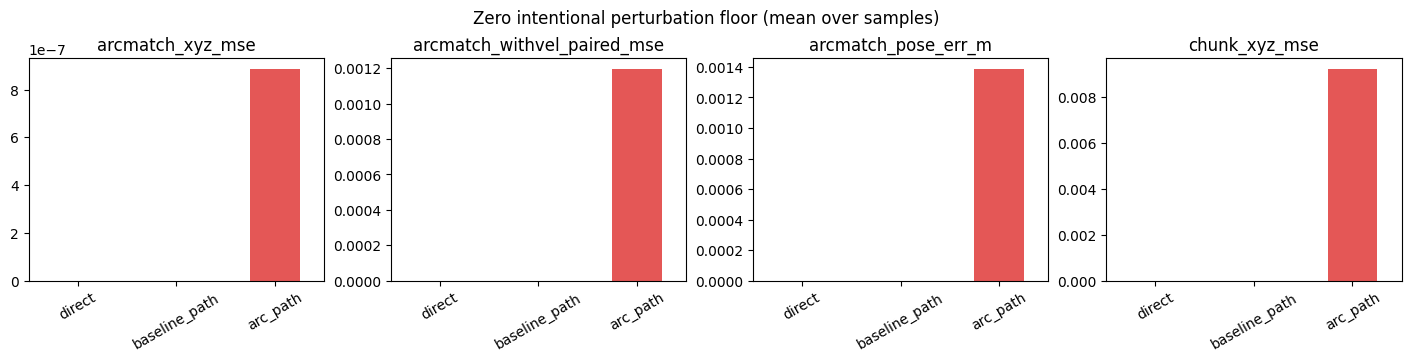

In [24]:
if "DF" not in globals() or "sweep" not in getattr(DF, "columns", []):
    raise RuntimeError(
        "DF is missing the 'sweep' column (often an empty DataFrame from a failed/skipped "
        "sweep cell). Re-run: Load trajectories → Sweep perturbations, then this cell."
    )

floor = (
    DF[(DF["sweep"] == "xyz_translation") & (DF["level"] == 0.0)]
    .groupby(["source", "mode"], as_index=False)[
        [
            "arcmatch_xyz_mse",
            "arcmatch_paired_mse",
            "arcmatch_withvel_paired_mse",
            "arcmatch_pose_err_m",
            "arcmatch_travel_ratio",
            "chunk_xyz_mse",
            "dtw_xyz_l2_m",
        ]
    ]
    .mean(numeric_only=True)
)
display(floor)

floor_plot = (
    DF[(DF["sweep"] == "xyz_translation") & (DF["level"] == 0.0)]
    .groupby("mode", as_index=False)[
        ["arcmatch_xyz_mse", "arcmatch_withvel_paired_mse", "arcmatch_pose_err_m", "chunk_xyz_mse"]
    ]
    .mean(numeric_only=True)
)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), constrained_layout=True)
keys = [
    "arcmatch_xyz_mse",
    "arcmatch_withvel_paired_mse",
    "arcmatch_pose_err_m",
    "chunk_xyz_mse",
]
for ax, key in zip(axes, keys):
    sub = floor_plot.set_index("mode").reindex(["direct", "baseline_path", "arc_path"])
    sub[key].plot(kind="bar", ax=ax, color=["#4c78a8", "#f58518", "#e45756"])
    ax.set_title(key)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("Zero intentional perturbation floor (mean over samples)")
plt.show()


## Metric vs perturbation — baseline_path vs arc_path overlays

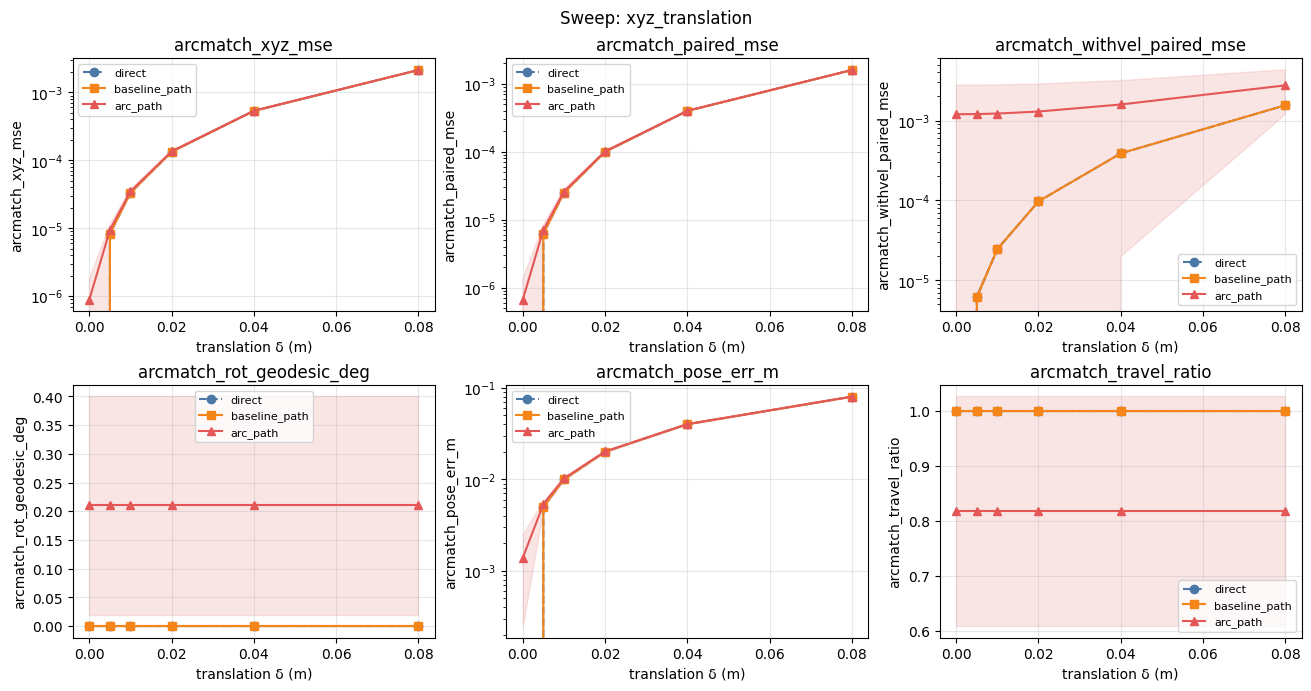

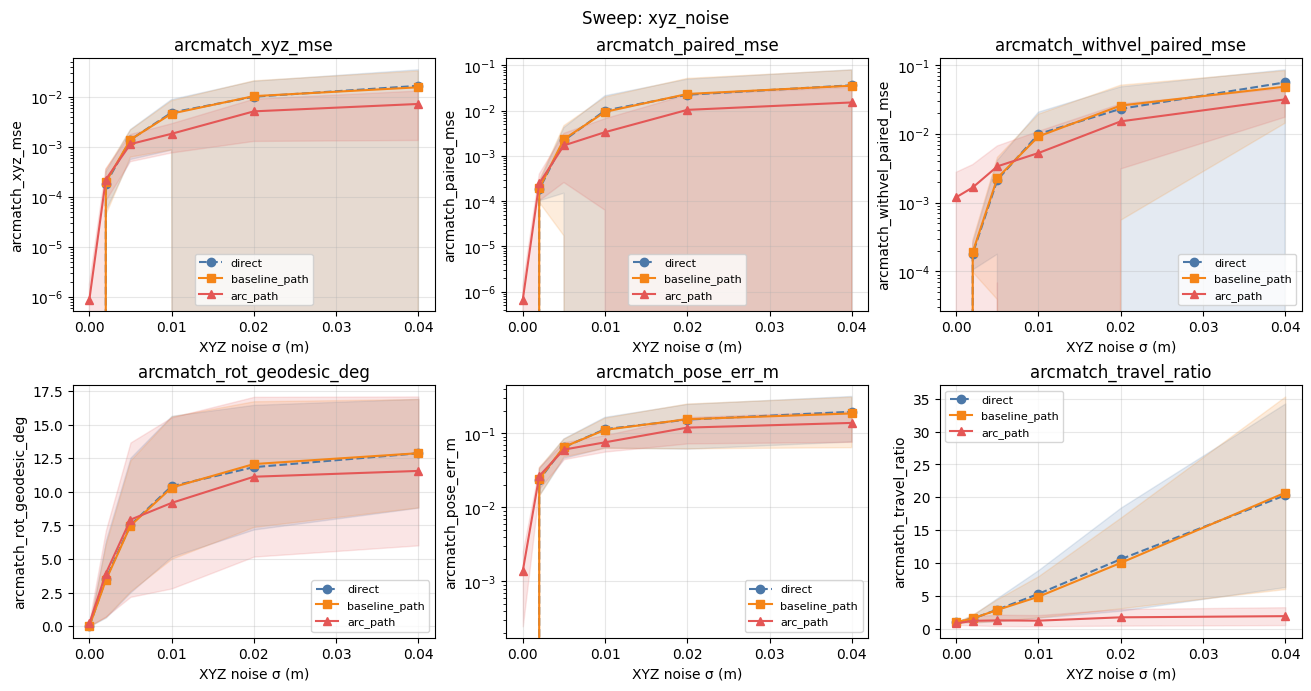

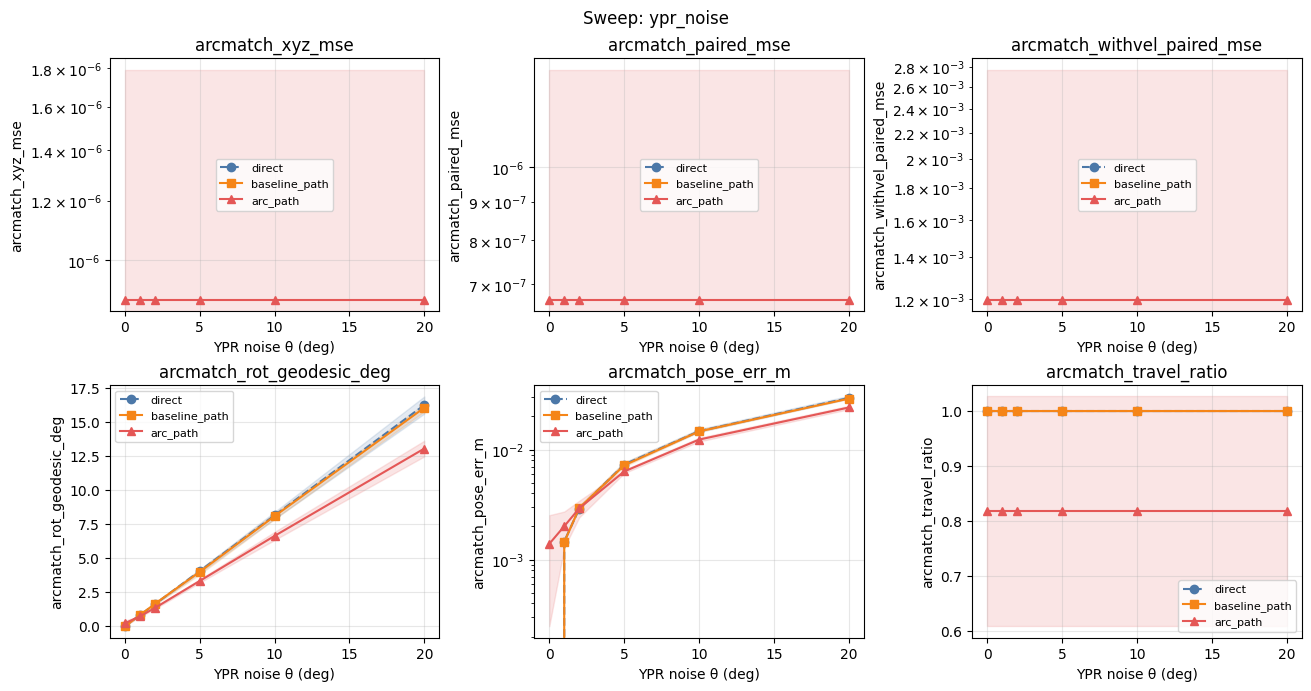

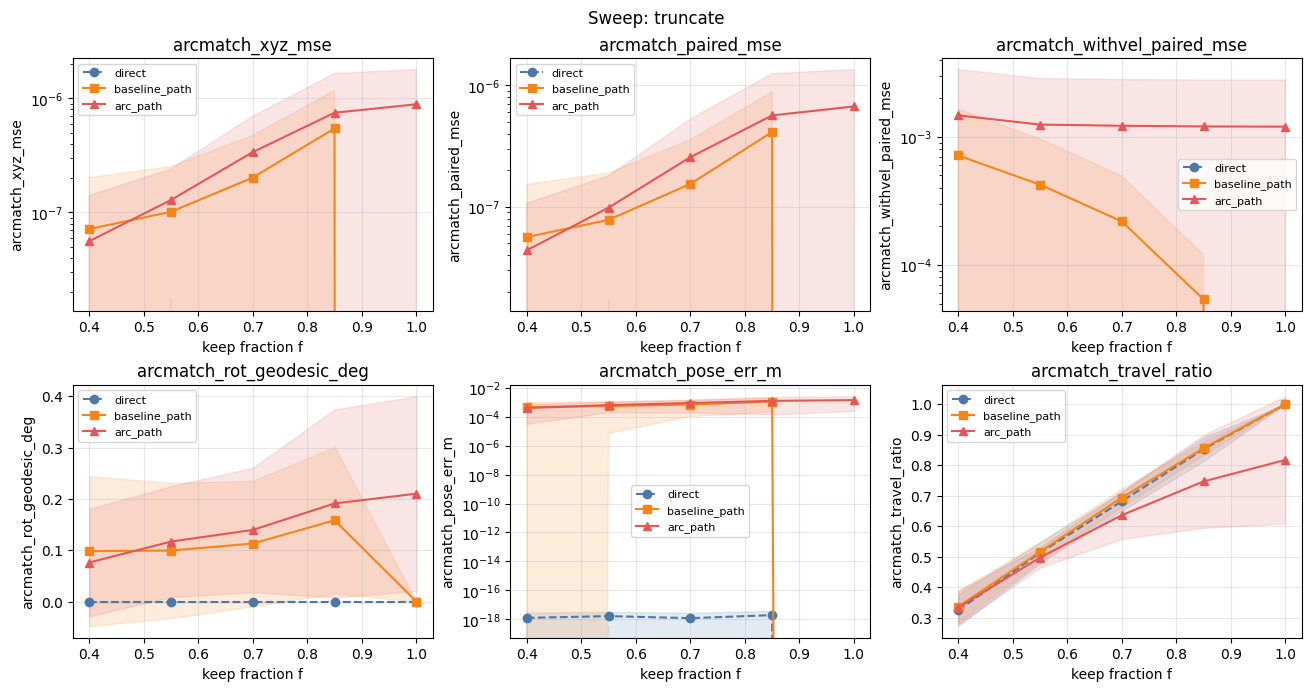

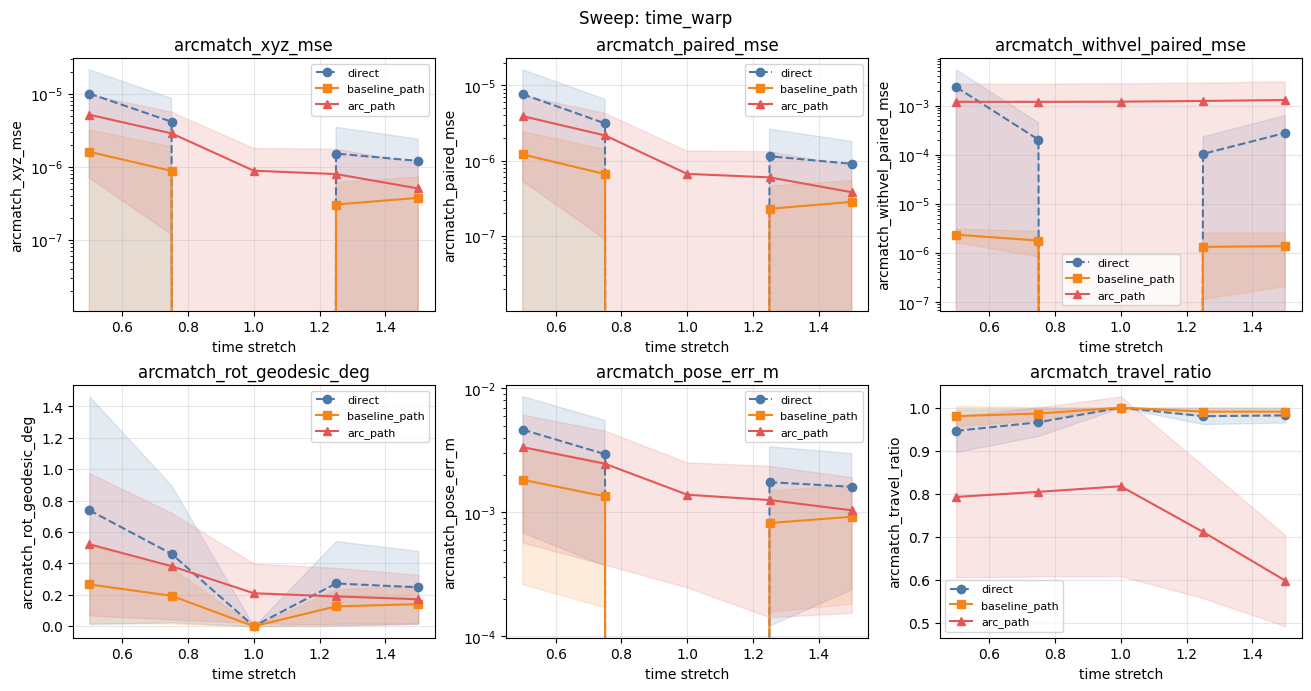

In [25]:
PLOT_METRICS = [
    "arcmatch_xyz_mse",
    "arcmatch_paired_mse",
    "arcmatch_withvel_paired_mse",
    "arcmatch_rot_geodesic_deg",
    "arcmatch_pose_err_m",
    "arcmatch_travel_ratio",
]
MODE_STYLE = {
    "direct": dict(color="#4c78a8", ls="--", marker="o", label="direct"),
    "baseline_path": dict(color="#f58518", ls="-", marker="s", label="baseline_path"),
    "arc_path": dict(color="#e45756", ls="-", marker="^", label="arc_path"),
}


def mean_curve(df: pd.DataFrame, sweep: str, mode: str, metric: str) -> pd.DataFrame:
    sub = df[(df["sweep"] == sweep) & (df["mode"] == mode)]
    g = sub.groupby("level")[metric].agg(["mean", "std"]).reset_index()
    g = g.rename(columns={"mean": metric, "std": f"{metric}_std"})
    return g


def plot_sweep(df: pd.DataFrame, sweep: str, metrics: list[str] | None = None):
    metrics = metrics or PLOT_METRICS
    xlabel = SWEEPS[sweep]["xlabel"]
    n = len(metrics)
    ncols = 3
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.4 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, metric in zip(axes, metrics):
        for mode, style in MODE_STYLE.items():
            curve = mean_curve(df, sweep, mode, metric)
            if curve.empty or metric not in curve.columns:
                continue
            ax.plot(curve["level"], curve[metric], **style)
            if f"{metric}_std" in curve.columns:
                ax.fill_between(
                    curve["level"],
                    curve[metric] - curve[f"{metric}_std"].fillna(0),
                    curve[metric] + curve[f"{metric}_std"].fillna(0),
                    color=style["color"],
                    alpha=0.15,
                )
        ax.set_xlabel(xlabel)
        ax.set_ylabel(metric)
        ax.set_title(metric)
        if metric.endswith("_mse") or metric.endswith("_m") or metric.endswith("_l2_m"):
            vals = df[(df["sweep"] == sweep) & df[metric].notna()][metric]
            pos = vals[vals > 0]
            if len(vals) and vals.max() > 0 and len(pos) and vals.max() / max(pos.min(), 1e-16) > 50:
                ax.set_yscale("log")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(f"Sweep: {sweep}")
    plt.show()


for sweep_name in SWEEPS:
    plot_sweep(DF, sweep_name)


## Ratio panel: `arc_path / baseline_path`

Systematic scale bias shows up as a ratio far from 1 across perturbation magnitudes.


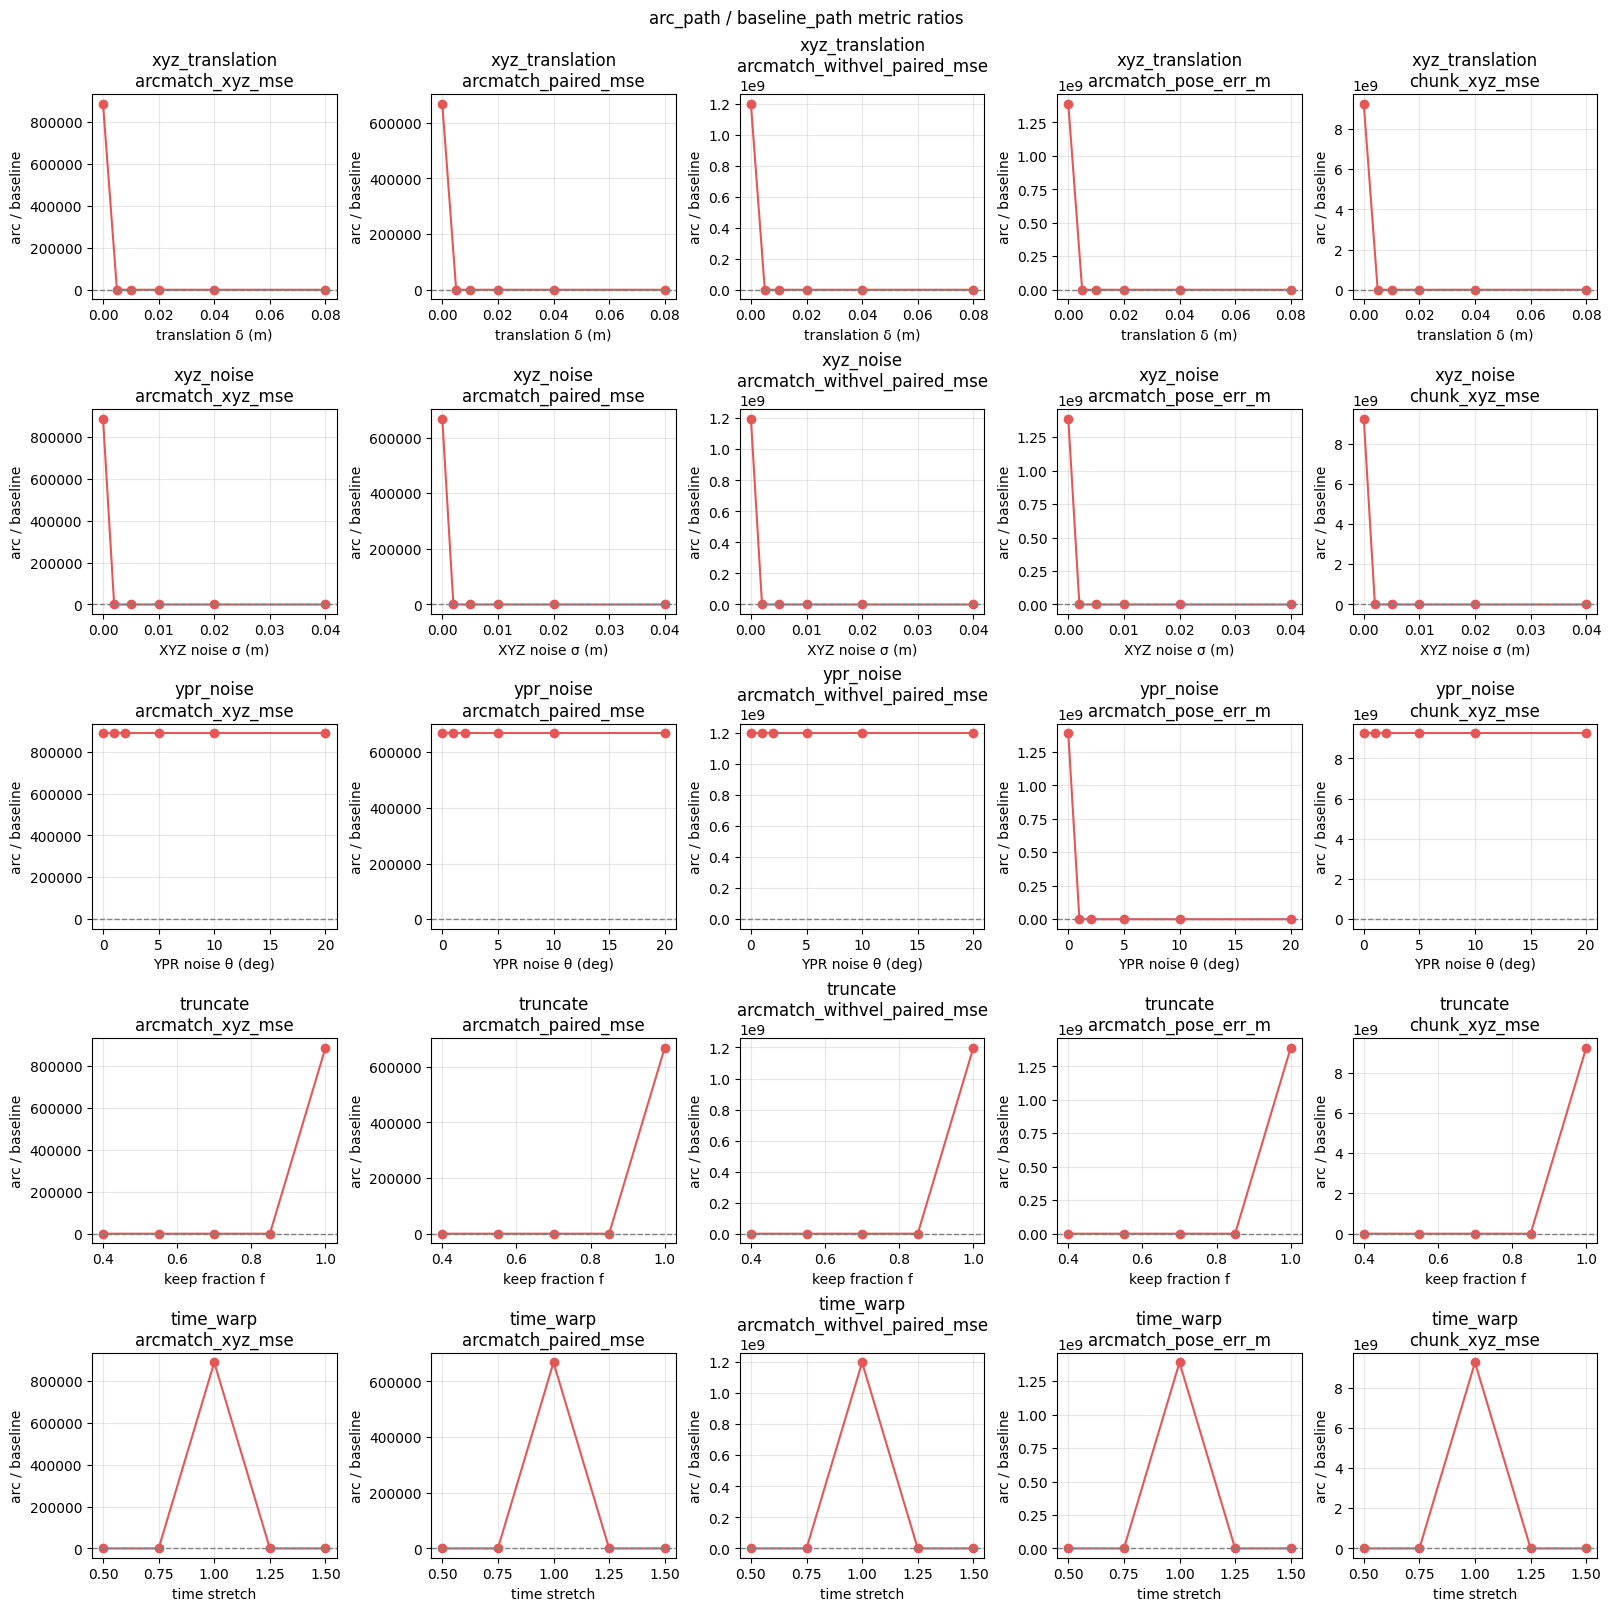

In [26]:
RATIO_METRICS = [
    "arcmatch_xyz_mse",
    "arcmatch_paired_mse",
    "arcmatch_withvel_paired_mse",
    "arcmatch_pose_err_m",
    "chunk_xyz_mse",
]


def ratio_frame(df: pd.DataFrame, sweep: str) -> pd.DataFrame:
    b = (
        df[(df["sweep"] == sweep) & (df["mode"] == "baseline_path")]
        .groupby(["source", "sample", "level"], as_index=False)[RATIO_METRICS]
        .mean()
    )
    a = (
        df[(df["sweep"] == sweep) & (df["mode"] == "arc_path")]
        .groupby(["source", "sample", "level"], as_index=False)[RATIO_METRICS]
        .mean()
    )
    m = b.merge(a, on=["source", "sample", "level"], suffixes=("_base", "_arc"))
    for metric in RATIO_METRICS:
        denom = m[f"{metric}_base"].abs().clip(lower=1e-12)
        m[f"{metric}_ratio"] = m[f"{metric}_arc"] / denom
    return m


fig, axes = plt.subplots(
    len(SWEEPS), len(RATIO_METRICS), figsize=(16, 3.2 * len(SWEEPS)), constrained_layout=True
)
if len(SWEEPS) == 1:
    axes = np.atleast_2d(axes)

for r, sweep_name in enumerate(SWEEPS):
    rf = ratio_frame(DF, sweep_name)
    for c, metric in enumerate(RATIO_METRICS):
        ax = axes[r, c]
        col = f"{metric}_ratio"
        curve = rf.groupby("level", as_index=False)[col].mean()
        ax.plot(curve["level"], curve[col], color="#e45756", marker="o")
        ax.axhline(1.0, color="gray", ls="--", lw=1)
        ax.set_title(f"{sweep_name}\n{metric}")
        ax.set_xlabel(SWEEPS[sweep_name]["xlabel"])
        ax.set_ylabel("arc / baseline")
        ax.grid(True, alpha=0.3)
fig.suptitle("arc_path / baseline_path metric ratios")
plt.show()


## Slope / R² of `arcmatch_xyz_mse` vs δ² and σ²

,mode,sweep,slope,r2,n
0,direct,xyz_translation,0.333333,1.000000,60
1,baseline_path,xyz_translation,0.333333,1.000000,60
2,arc_path,xyz_translation,0.334163,0.999877,60
3,direct,xyz_noise,11.461141,0.272898,60
4,baseline_path,xyz_noise,10.856422,0.250719,60
5,arc_path,xyz_noise,5.078770,0.334138,60


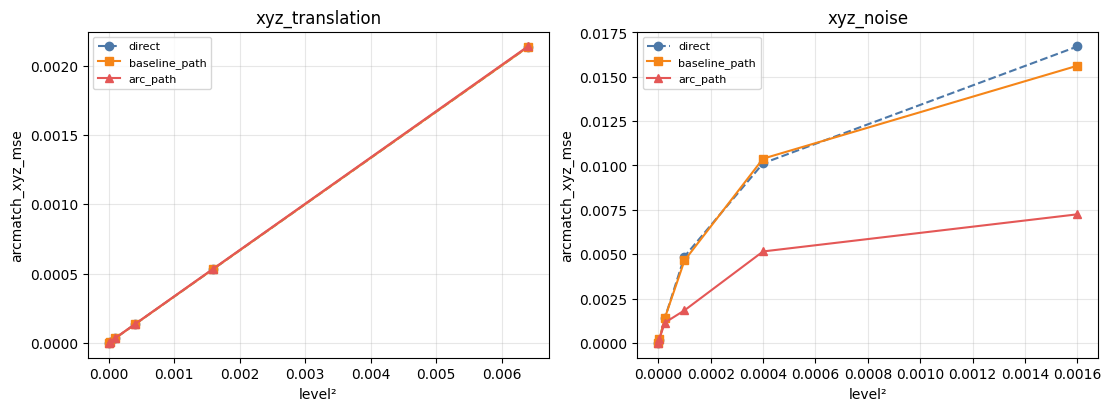

In [27]:
def fit_mse_vs_sq(df: pd.DataFrame, sweep: str, mode: str) -> dict:
    sub = df[(df["sweep"] == sweep) & (df["mode"] == mode)].copy()
    if sub.empty:
        return {"mode": mode, "sweep": sweep, "slope": np.nan, "r2": np.nan, "n": 0}
    x = (sub["level"].to_numpy(dtype=np.float64)) ** 2
    y = sub["arcmatch_xyz_mse"].to_numpy(dtype=np.float64)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 2 or np.allclose(x, x[0]):
        return {"mode": mode, "sweep": sweep, "slope": np.nan, "r2": np.nan, "n": len(x)}
    slope = float(np.dot(x, y) / np.dot(x, x))
    yhat = slope * x
    ss_res = float(np.sum((y - yhat) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return {"mode": mode, "sweep": sweep, "slope": slope, "r2": r2, "n": len(x)}


fit_rows = []
for sweep in ("xyz_translation", "xyz_noise"):
    for mode in ("direct", "baseline_path", "arc_path"):
        fit_rows.append(fit_mse_vs_sq(DF, sweep, mode))
FIT = pd.DataFrame(fit_rows)
display(FIT)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, sweep in zip(axes, ("xyz_translation", "xyz_noise")):
    for mode, style in MODE_STYLE.items():
        sub = DF[(DF["sweep"] == sweep) & (DF["mode"] == mode)]
        g = sub.groupby("level", as_index=False)["arcmatch_xyz_mse"].mean()
        ax.plot(g["level"] ** 2, g["arcmatch_xyz_mse"], **style)
    ax.set_xlabel("level²")
    ax.set_ylabel("arcmatch_xyz_mse")
    ax.set_title(sweep)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.show()


## Path sketch (one sample, mid translation)

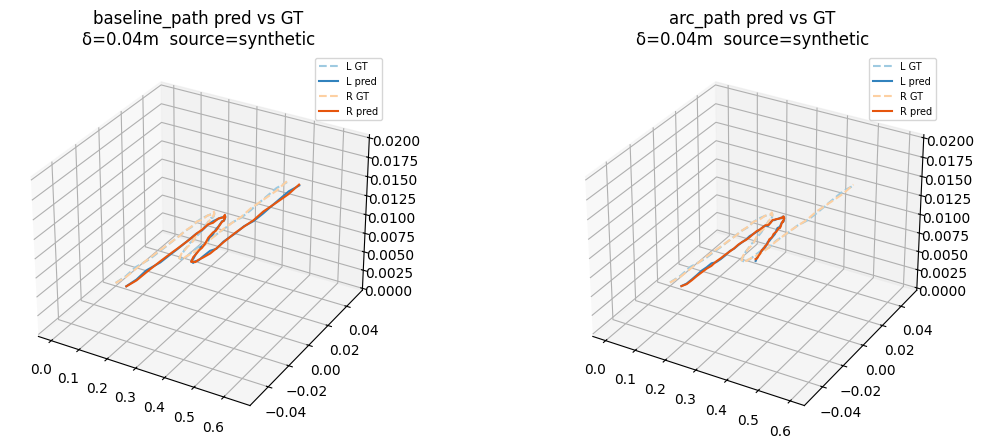

baseline_path {'arcmatch_paired_mse': 0.0004, 'arcmatch_withvel_paired_mse': 0.000389, 'arcmatch_xyz_mse': 0.000533, 'arcmatch_rot_geodesic_deg': 0.0, 'arcmatch_pose_err_m': 0.04, 'arcmatch_final_xyz_l2_m': 0.04, 'arcmatch_span_m': 0.639575, 'arcmatch_travel_ratio': 1.0}
arc_path      {'arcmatch_paired_mse': 0.000399, 'arcmatch_withvel_paired_mse': 0.002983, 'arcmatch_xyz_mse': 0.000532, 'arcmatch_rot_geodesic_deg': 0.001765, 'arcmatch_pose_err_m': 0.039943, 'arcmatch_final_xyz_l2_m': 0.039878, 'arcmatch_span_m': 0.399887, 'arcmatch_travel_ratio': 0.625239}


In [28]:
demo_src = next(iter(TRAJECTORIES))
demo_full = TRAJECTORIES[demo_src][0]
demo_gt = to_gt(demo_full)
demo_delta = 0.04
demo_pert = perturb_xyz_translation(demo_full, demo_delta)
demo_base = baseline_pred_path(demo_pert)
demo_arc = arc_pred_path(demo_pert)

fig = plt.figure(figsize=(12, 4.5))
for i, (title, pred) in enumerate(
    (
        ("baseline_path pred vs GT", demo_base),
        ("arc_path pred vs GT", demo_arc),
    ),
    start=1,
):
    ax = fig.add_subplot(1, 2, i, projection="3d")
    for cols, name, c_gt, c_pr in (
        (ARM_XYZ[0], "L", "#9ecae1", "#3182bd"),
        (ARM_XYZ[1], "R", "#fdd0a2", "#e6550d"),
    ):
        g = demo_gt[:, list(cols)]
        p = pred[:, list(cols)]
        ax.plot(g[:, 0], g[:, 1], g[:, 2], color=c_gt, ls="--", label=f"{name} GT")
        ax.plot(p[:, 0], p[:, 1], p[:, 2], color=c_pr, label=f"{name} pred")
    ax.set_title(f"{title}\nδ={demo_delta}m  source={demo_src}")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

print("baseline_path", {k: round(v, 6) for k, v in score_pair(demo_base, demo_gt).items() if k.startswith("arcmatch")})
print("arc_path     ", {k: round(v, 6) for k, v in score_pair(demo_arc, demo_gt).items() if k.startswith("arcmatch")})


## Per-waypoint withvel arcmatch (vs production mean-vel)

Production `arcmatch_withvel_paired_mse` appends **one** mean velocity row
(`tokenize_span`: `(p_end - p_start) / duration`). That is the `mean` codec layout.

This section also scores a **per-waypoint** withvel variant: after the same
span-matched waypoint resample, append **M interval rates**
`(wp[i+1]-wp[i]) / dt_i` (last row repeats), matching the `per_waypoint`
tokenizer layout. Waypoint MSE is unchanged; only the velocity term differs.

Also compares ARC pred paths built with tokenizer `velocity_mode="mean"`
vs `"per_waypoint"` (detok timing differs; scorer is shared).



In [29]:
from egomimic.eval.arc_metrics import (
    BIMANUAL_DIM,
    PAIRED_COLS,
    _arm_views,
    _dist_interval_indices,
    cumulative_arc_length,
    match_spans,
    mse,
    resample_by_distance,
    tokenize_span,
    arm_travel,
)


def per_waypoint_vel_from_traj(
    traj: np.ndarray, spans: np.ndarray, num_points: int, dt: float
) -> tuple[np.ndarray, np.ndarray]:
    """Span-matched waypoints + M interval velocities (last row = pad)."""
    waypoints = np.zeros((num_points, BIMANUAL_DIM), dtype=np.float64)
    times = np.zeros((num_points, 2), dtype=np.float64)
    for arm, (pos, ypr, grip) in enumerate(_arm_views(traj)):
        cum = cumulative_arc_length(pos)
        end_s = float(min(spans[arm], cum[-1]))
        p, y, g = resample_by_distance(
            pos, ypr, grip, cum, 0.0, end_s, num_points, start_idx=0
        )
        off = arm * 7
        waypoints[:, off : off + 3] = p
        waypoints[:, off + 3 : off + 6] = y
        waypoints[:, off + 6] = g[:, 0]
        for i, s in enumerate(np.linspace(0.0, end_s, num_points)):
            _, end_i = _dist_interval_indices(cum, 0.0, float(s))
            times[i, arm] = max(end_i, 0) * dt
    t = times.mean(axis=1)
    dt_iv = np.diff(t)
    safe = np.where(dt_iv > 1e-9, dt_iv, np.inf)
    vel = np.zeros_like(waypoints)
    for off, width in ((0, 3), (3, 3), (6, 1), (7, 3), (10, 3), (13, 1)):
        block = waypoints[:, off : off + width]
        rate = np.diff(block, axis=0) / safe[:, None]
        vel[:-1, off : off + width] = rate
        vel[-1, off : off + width] = rate[-1]
    return waypoints, vel


def arcmatch_mean_and_pw(pred: np.ndarray, gt: np.ndarray) -> dict[str, float]:
    """Shared span match; report mean-vel and per-waypoint-vel withvel MSEs."""
    span = match_spans(pred, gt)
    if not np.all(np.isfinite(span)):
        return {}
    pw, pv_mean = tokenize_span(pred, span, ARCMATCH_POINTS, METRIC_DT)
    gw, gv_mean = tokenize_span(gt, span, ARCMATCH_POINTS, METRIC_DT)
    _, pv_pw = per_waypoint_vel_from_traj(pred, span, ARCMATCH_POINTS, METRIC_DT)
    _, gv_pw = per_waypoint_vel_from_traj(gt, span, ARCMATCH_POINTS, METRIC_DT)
    pred_mean = np.concatenate([pw, pv_mean[None]], axis=0)
    gt_mean = np.concatenate([gw, gv_mean[None]], axis=0)
    pred_pw = np.concatenate([pw, pv_pw], axis=0)
    gt_pw = np.concatenate([gw, gv_pw], axis=0)
    return {
        "arcmatch_xyz_mse": mse(pw[None], gw[None], XYZ_COLS),
        "arcmatch_paired_mse": mse(pw[None], gw[None], PAIRED_COLS),
        "arcmatch_withvel_paired_mse": mse(pred_mean[None], gt_mean[None], PAIRED_COLS),
        "arcmatch_withvel_paired_mse_pw": mse(pred_pw[None], gt_pw[None], PAIRED_COLS),
        "arcmatch_vel_mse_mean": float(np.mean((pv_mean - gv_mean) ** 2)),
        "arcmatch_vel_mse_pw": float(np.mean((pv_pw - gv_pw) ** 2)),
        "arcmatch_span_m": float(np.mean(span)),
        "arcmatch_travel_ratio": float(
            np.mean(arm_travel(pred) / np.maximum(arm_travel(gt), 1e-6))
        ),
    }


def make_tokenizer(velocity_mode: str) -> TokenizeBimanualArcLengthCartesian:
    return TokenizeBimanualArcLengthCartesian(
        action_key="actions_cartesian",
        output_action_key="actions_cartesian",
        min_distance_unit=MIN_DISTANCE_UNIT,
        resampled_vector_length=RESAMPLED_VECTOR_LENGTH,
        velocity_mode=velocity_mode,
    )


def arc_pred_path_with(
    tokenizer: TokenizeBimanualArcLengthCartesian, chunk: np.ndarray
) -> np.ndarray:
    token = tokenizer.transform(
        {"actions_cartesian": np.asarray(chunk, dtype=np.float64)}
    )["actions_cartesian"]
    return tokenizer.detokenize(token, ACTION_HORIZON)


TOKENIZER_MEAN = make_tokenizer("mean")
TOKENIZER_PW = make_tokenizer("per_waypoint")
_demo = next(iter(TRAJECTORIES.values()))[0]
print(
    "tokenizers ready: mean",
    TOKENIZER_MEAN.transform({"actions_cartesian": _demo})["actions_cartesian"].shape,
    "| pw",
    TOKENIZER_PW.transform({"actions_cartesian": _demo})["actions_cartesian"].shape,
)



tokenizers ready: mean (101, 14) | pw (200, 14)


In [30]:
# Floor + translation/noise grid for mean vs per-waypoint withvel,
# and ARC detok under both tokenizer velocity modes.
VEL_SWEEPS = {
    "xyz_translation": [0.0, 0.01, 0.02, 0.04, 0.08],
    "xyz_noise": [0.0, 0.005, 0.01, 0.02, 0.04],
}
PW_ROWS: list[dict] = []

for src_name, chunks in TRAJECTORIES.items():
    for sample_i, full in enumerate(chunks):
        full = np.asarray(full, dtype=np.float64)
        gt = to_gt(full)
        for tok_name, tok in (("mean", TOKENIZER_MEAN), ("per_waypoint", TOKENIZER_PW)):
            for sweep_name, levels in VEL_SWEEPS.items():
                for level in levels:
                    seed = abs(
                        hash((src_name, sample_i, sweep_name, float(level), tok_name))
                    ) % (2**32)
                    rng = np.random.default_rng(seed)
                    if sweep_name == "xyz_translation":
                        pert_full = perturb_xyz_translation(full, level)
                        pert_gt = perturb_xyz_translation(gt, level)
                    else:
                        pert_full = perturb_xyz_noise(full, level, rng)
                        pert_gt = perturb_xyz_noise(
                            gt, level, np.random.default_rng(seed)
                        )

                    paths = {
                        "direct": pert_gt,
                        "baseline_path": baseline_pred_path(pert_full),
                        "arc_path": arc_pred_path_with(tok, pert_full),
                    }
                    for mode, pred in paths.items():
                        metrics = arcmatch_mean_and_pw(pred, gt)
                        if not metrics:
                            continue
                        PW_ROWS.append(
                            {
                                "source": src_name,
                                "sample": sample_i,
                                "tokenizer_vel": tok_name,
                                "sweep": sweep_name,
                                "level": float(level),
                                "mode": mode,
                                **metrics,
                            }
                        )

DF_PW = pd.DataFrame(PW_ROWS)
print("DF_PW", DF_PW.shape)
floor_pw = (
    DF_PW[(DF_PW["sweep"] == "xyz_translation") & (DF_PW["level"] == 0.0)]
    .groupby(["tokenizer_vel", "mode"], as_index=False)[
        [
            "arcmatch_xyz_mse",
            "arcmatch_withvel_paired_mse",
            "arcmatch_withvel_paired_mse_pw",
            "arcmatch_vel_mse_mean",
            "arcmatch_vel_mse_pw",
            "arcmatch_span_m",
            "arcmatch_travel_ratio",
        ]
    ]
    .mean(numeric_only=True)
)
display(floor_pw)



DF_PW (600, 14)


,tokenizer_vel,mode,arcmatch_xyz_mse,arcmatch_withvel_paired_mse,arcmatch_withvel_paired_mse_pw,arcmatch_vel_mse_mean,arcmatch_vel_mse_pw,arcmatch_span_m,arcmatch_travel_ratio
0,mean,arc_path,1.043899e-06,0.001200,0.018903,0.027480,0.055980,0.273792,0.819091
1,mean,baseline_path,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.395554,1.000000
2,mean,direct,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.395554,1.000000
3,per_waypoint,arc_path,8.875880e-07,0.001198,0.017824,0.027452,0.049159,0.273530,0.817245
4,per_waypoint,baseline_path,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.395554,1.000000
5,per_waypoint,direct,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.395554,1.000000


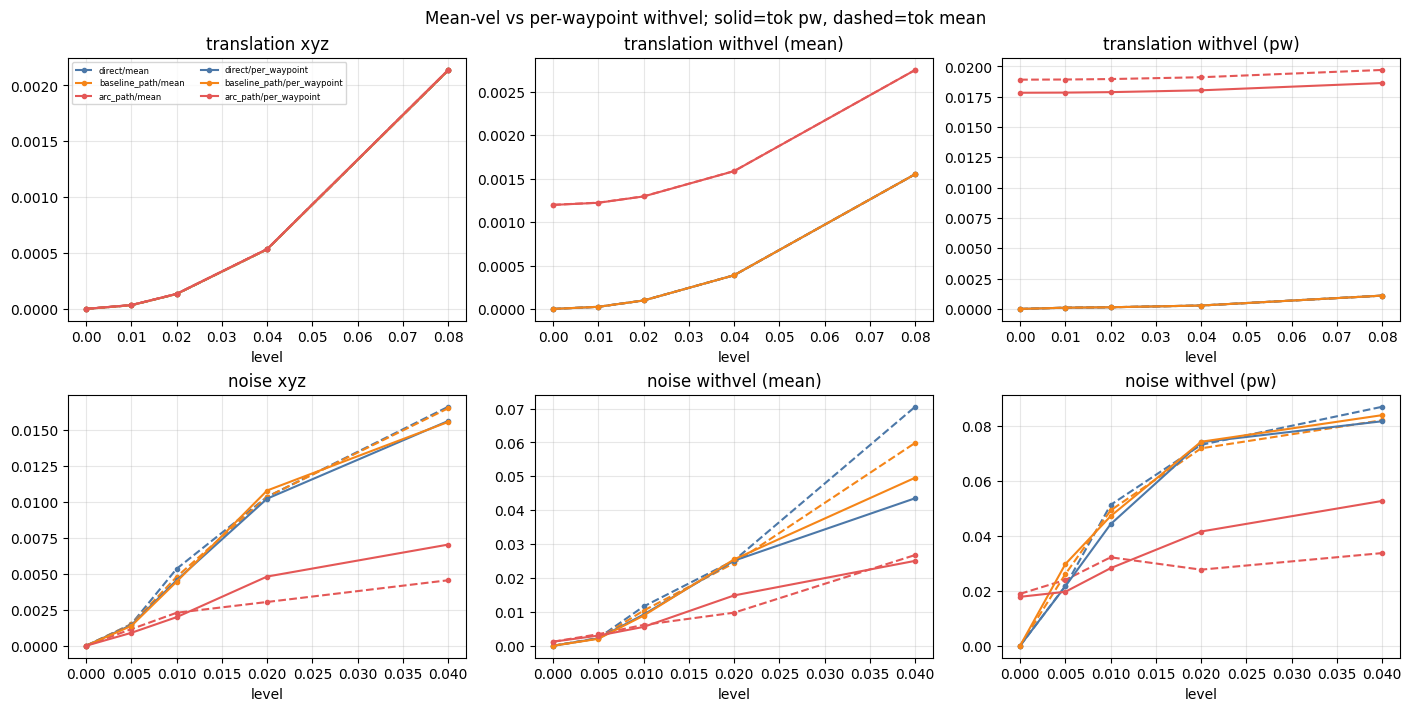

,xyz arc/base,wv_mean arc/base,wv_pw arc/base
level,,,
0.000,NaN,NaN,NaN
0.005,0.652311,1.454699,0.661213
0.010,0.446351,0.625826,0.598661
0.020,0.445835,0.582813,0.559997
0.040,0.452100,0.505353,0.628074


In [31]:
def _pw_curve(df: pd.DataFrame, sweep: str, tok: str, metric: str) -> pd.DataFrame:
    sub = df[(df["sweep"] == sweep) & (df["tokenizer_vel"] == tok)]
    return (
        sub.groupby(["level", "mode"], as_index=False)[metric]
        .mean()
        .pivot(index="level", columns="mode", values=metric)
    )


fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
plot_specs = [
    ("xyz_translation", "arcmatch_xyz_mse", "translation xyz"),
    ("xyz_translation", "arcmatch_withvel_paired_mse", "translation withvel (mean)"),
    ("xyz_translation", "arcmatch_withvel_paired_mse_pw", "translation withvel (pw)"),
    ("xyz_noise", "arcmatch_xyz_mse", "noise xyz"),
    ("xyz_noise", "arcmatch_withvel_paired_mse", "noise withvel (mean)"),
    ("xyz_noise", "arcmatch_withvel_paired_mse_pw", "noise withvel (pw)"),
]
for ax, (sweep, metric, title) in zip(axes.ravel(), plot_specs):
    for tok, ls in (("mean", "--"), ("per_waypoint", "-")):
        cur = _pw_curve(DF_PW, sweep, tok, metric)
        for mode, color in (
            ("direct", "#4c78a8"),
            ("baseline_path", "#f58518"),
            ("arc_path", "#e45756"),
        ):
            if mode not in cur.columns:
                continue
            ax.plot(
                cur.index,
                cur[mode],
                color=color,
                ls=ls,
                marker="o",
                ms=3,
                label=f"{mode}/{tok}",
            )
    ax.set_title(title)
    ax.set_xlabel("level")
    ax.grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=6, ncol=2)
fig.suptitle("Mean-vel vs per-waypoint withvel; solid=tok pw, dashed=tok mean")
plt.show()

noise_xyz = _pw_curve(DF_PW, "xyz_noise", "per_waypoint", "arcmatch_xyz_mse")
noise_wv = _pw_curve(DF_PW, "xyz_noise", "per_waypoint", "arcmatch_withvel_paired_mse")
noise_wvpw = _pw_curve(
    DF_PW, "xyz_noise", "per_waypoint", "arcmatch_withvel_paired_mse_pw"
)
ratio = pd.DataFrame(
    {
        "xyz arc/base": noise_xyz["arc_path"]
        / noise_xyz["baseline_path"].replace(0, np.nan),
        "wv_mean arc/base": noise_wv["arc_path"]
        / noise_wv["baseline_path"].replace(0, np.nan),
        "wv_pw arc/base": noise_wvpw["arc_path"]
        / noise_wvpw["baseline_path"].replace(0, np.nan),
    }
)
display(ratio)



## Shared-D token-space arcmatch (fair baseline vs ARC)

Score **only in waypoint space** (M points) on a **shared distance**:

`shared_arm = min(L_gt_arm, D, pred_travel_arm)`

**ARC detok rule:** do **not** detokenize ARC for scoring when `L_gt >= D`.
Stay in token/waypoint space (native span ~D), resample both sides to M over
`shared ~= D`. Detok ARC **only when baseline/GT travel is shorter than D**,
so both trajectories can be re-tokenized over that same shorter distance with
the same M.

Prep default here is **T=100** (tokenizer resolution). T=45 deinterp remains
available for production-travel comparisons.



In [32]:
from egomimic.eval.arc_metrics import (
    PAIRED_COLS,
    XYZ_COLS,
    arm_travel,
    mse,
    tokenize_span,
)


def travel_45(chunk: np.ndarray) -> np.ndarray:
    """Per-arm travel of the deinterp-45 window (metres)."""
    return arm_travel(to_gt(chunk))


def arc_tokens(chunk: np.ndarray, tokenizer=None) -> np.ndarray:
    """Full ARC token block for a chunk (waypoints + velocity rows)."""
    tok = tokenizer if tokenizer is not None else TOKENIZER
    return np.asarray(
        tok.transform({"actions_cartesian": np.asarray(chunk, dtype=np.float64)})[
            "actions_cartesian"
        ],
        dtype=np.float64,
    )


def arc_waypoint_polyline(chunk: np.ndarray, tokenizer=None) -> np.ndarray:
    """ARC-token waypoints (M_tok, 14). Span ~D by construction; drop vel rows."""
    tokens = arc_tokens(chunk, tokenizer=tokenizer)
    M = int(RESAMPLED_VECTOR_LENGTH)
    if tokens.shape[0] < M:
        raise ValueError(f"expected >= {M} token rows, got {tokens.shape}")
    return tokens[:M].copy()


def shared_spans(gt_ti: np.ndarray, pred_travel: np.ndarray, D: float) -> np.ndarray:
    """Per-arm shared distance: min(L_gt, D, pred_travel)."""
    L = arm_travel(gt_ti)
    D_arr = np.full(2, float(D), dtype=np.float64)
    return np.minimum(np.minimum(L, pred_travel), D_arr)


def score_shared_d(
    pred_traj: np.ndarray,
    gt_ti: np.ndarray,
    *,
    D: float | None = None,
    num_points: int | None = None,
    dt: float | None = None,
    pred_is_arc_waypoints: bool = False,
    arc_full_chunk: np.ndarray | None = None,
) -> dict[str, float]:
    """Waypoint MSE on shared = min(L_gt, D, pred_travel).

    ARC detok is used **only** when baseline/GT travel is shorter than D on any
    arm: then both sides must be time-indexed and re-tokenized over that shorter
    shared distance with the same M. If L_gt >= D, ARC stays in token/waypoint
    space (no detok) and both are resampled to M over shared ~= D.

    Prefer gt_ti / baseline pred at T=100 (tokenizer resolution).
    """
    D = float(MIN_DISTANCE_UNIT if D is None else D)
    num_points = int(ARCMATCH_POINTS if num_points is None else num_points)
    dt = float(METRIC_DT if dt is None else dt)
    gt_ti = np.asarray(gt_ti, dtype=np.float64)
    pred_traj = np.asarray(pred_traj, dtype=np.float64)
    L = arm_travel(gt_ti)

    used_detok = False
    if pred_is_arc_waypoints:
        # Default ARC geometry: token waypoints spanning ~D.
        P = arm_travel(pred_traj)
        # Detok ONLY when GT/baseline is shorter than D -- need a time-indexed
        # ARC traj so tokenize_span can cover shared < D with the same M.
        if np.any(L < D - 1e-12):
            if arc_full_chunk is None:
                raise ValueError(
                    "L_gt < D requires arc_full_chunk so ARC can be detokenized "
                    "then re-tokenized over the shorter shared span"
                )
            pred_traj = arc_pred_path(np.asarray(arc_full_chunk, dtype=np.float64))
            P = arm_travel(pred_traj)
            used_detok = True
            pred_is_arc_waypoints = False  # now time-indexed
        spans = shared_spans(gt_ti, P, D)
    else:
        P = arm_travel(pred_traj)
        spans = shared_spans(gt_ti, P, D)

    if not np.all(np.isfinite(spans)) or np.any(spans <= 0):
        return {}

    pw, _ = tokenize_span(pred_traj, spans, num_points, dt)
    gw, _ = tokenize_span(gt_ti, spans, num_points, dt)
    return {
        "shared_d_xyz_mse": mse(pw[None], gw[None], XYZ_COLS),
        "shared_d_paired_mse": mse(pw[None], gw[None], PAIRED_COLS),
        "shared_span_m": float(np.mean(spans)),
        "Lgt_m": float(np.mean(L)),
        "D": D,
        "pred_travel_m": float(np.mean(P)),
        "travel_ratio": float(np.mean(P / np.maximum(L, 1e-6))),
        "shared_L": float(spans[0]),
        "shared_R": float(spans[1]),
        "arc_used_detok": float(used_detok),
        "gt_shorter_than_D": float(bool(np.any(L < D - 1e-12))),
    }


def score_shared_d_modes(
    pert_full: np.ndarray,
    gt_full: np.ndarray,
    *,
    prep: str = "T100",
) -> dict[str, dict[str, float]]:
    """Score direct / baseline_path / arc_path under shared-D.

    prep: \"T100\" keeps GT/baseline at chunk length; \"T45\" deinterps to 45.
    """
    full = np.asarray(gt_full, dtype=np.float64)
    pert = np.asarray(pert_full, dtype=np.float64)
    if prep == "T45":
        gt_ti = to_gt(full)
        base_pred = baseline_pred_path(pert)
        # direct caller should pass already-perturbed gt; here identity helper
        direct_pred = gt_ti
    else:
        gt_ti = full if full.shape[-2] == pert.shape[-2] else to_gt(full)
        # Prefer native length (100). If somehow shorter, leave as-is.
        gt_ti = np.asarray(full, dtype=np.float64)
        base_pred = np.asarray(pert, dtype=np.float64)
        direct_pred = gt_ti

    arc_wp = arc_waypoint_polyline(pert)
    return {
        "direct": score_shared_d(direct_pred, gt_ti, pred_is_arc_waypoints=False),
        "baseline_path": score_shared_d(base_pred, gt_ti, pred_is_arc_waypoints=False),
        "arc_path": score_shared_d(
            arc_wp,
            gt_ti,
            pred_is_arc_waypoints=True,
            arc_full_chunk=pert,
        ),
    }


print(
    "shared-D helpers ready; D=",
    MIN_DISTANCE_UNIT,
    "M_score=",
    ARCMATCH_POINTS,
    "M_tok=",
    RESAMPLED_VECTOR_LENGTH,
    "| ARC detok only when L_gt < D",
)



shared-D helpers ready; D= 0.4 M_score= 32 M_tok= 100


In [33]:
# Shared-D sweeps (T100 prep). ARC detok only if L_gt < D.
SHARED_SWEEPS = {
    "xyz_translation": [0.0, 0.005, 0.01, 0.02, 0.04, 0.08],
    "xyz_noise": [0.0, 0.002, 0.005, 0.01, 0.02, 0.04],
    # Truncate drives L_gt < D so ARC must detok then re-tokenize at shared.
    "truncate": [1.0, 0.5, 0.35, 0.25],
}
SD_ROWS: list[dict] = []

for src_name, chunks in TRAJECTORIES.items():
    for sample_i, full in enumerate(chunks):
        full = np.asarray(full, dtype=np.float64)
        gt_ti = full  # T100 prep
        gt_45 = to_gt(full)
        for sweep_name, levels in SHARED_SWEEPS.items():
            for level in levels:
                seed = abs(hash((src_name, sample_i, sweep_name, float(level), "sd"))) % (
                    2**32
                )
                rng = np.random.default_rng(seed)
                if sweep_name == "xyz_translation":
                    pert_full = perturb_xyz_translation(full, level)
                    direct_pred = perturb_xyz_translation(gt_ti, level)
                elif sweep_name == "xyz_noise":
                    pert_full = perturb_xyz_noise(full, level, rng)
                    direct_pred = perturb_xyz_noise(
                        gt_ti, level, np.random.default_rng(seed)
                    )
                else:
                    pert_full = perturb_truncate(full, level)
                    direct_pred = perturb_truncate(gt_ti, level)

                base_pred = pert_full  # T100: no deinterp
                arc_wp = arc_waypoint_polyline(pert_full)
                # For truncate, GT for shared-D should be the truncated GT so L_gt
                # reflects the shorter trajectory we are scoring against.
                gt_for_score = direct_pred if sweep_name == "truncate" else gt_ti

                scored = {
                    "direct": score_shared_d(direct_pred, gt_for_score),
                    "baseline_path": score_shared_d(base_pred, gt_for_score),
                    "arc_path": score_shared_d(
                        arc_wp,
                        gt_for_score,
                        pred_is_arc_waypoints=True,
                        arc_full_chunk=pert_full,
                    ),
                }
                old_map = {
                    "direct": score_pair(
                        direct_pred if len(direct_pred) == len(gt_45) else to_gt(direct_pred),
                        gt_45,
                    ),
                    "baseline_path": score_pair(baseline_pred_path(pert_full), gt_45),
                    "arc_path": score_pair(arc_pred_path(pert_full), gt_45),
                }
                for mode, metrics in scored.items():
                    if not metrics:
                        continue
                    SD_ROWS.append(
                        {
                            "source": src_name,
                            "sample": sample_i,
                            "sweep": sweep_name,
                            "level": float(level),
                            "mode": mode,
                            **metrics,
                            "old_arcmatch_xyz_mse": old_map[mode].get("arcmatch_xyz_mse"),
                            "old_arcmatch_withvel_paired_mse": old_map[mode].get(
                                "arcmatch_withvel_paired_mse"
                            ),
                        }
                    )

DF_SD = pd.DataFrame(SD_ROWS)
print("DF_SD", DF_SD.shape)
print(
    "ARC detok rate by sweep (arc_path only):",
    DF_SD[DF_SD["mode"] == "arc_path"]
    .groupby("sweep")["arc_used_detok"]
    .mean()
    .to_dict(),
)

floor_sd = (
    DF_SD[(DF_SD["sweep"] == "xyz_translation") & (DF_SD["level"] == 0.0)]
    .groupby(["source", "mode"], as_index=False)[
        [
            "shared_d_xyz_mse",
            "shared_d_paired_mse",
            "shared_span_m",
            "Lgt_m",
            "pred_travel_m",
            "arc_used_detok",
            "gt_shorter_than_D",
            "old_arcmatch_xyz_mse",
            "old_arcmatch_withvel_paired_mse",
        ]
    ]
    .mean(numeric_only=True)
)
display(floor_sd)

trunc = (
    DF_SD[DF_SD["sweep"] == "truncate"]
    .groupby(["level", "mode"], as_index=False)[
        [
            "shared_d_xyz_mse",
            "shared_span_m",
            "Lgt_m",
            "arc_used_detok",
            "gt_shorter_than_D",
        ]
    ]
    .mean(numeric_only=True)
)
print("Truncate sweep (detok should turn on when L_gt < D):")
display(trunc)



DF_SD (360, 16)


,source,mode,shared_d_xyz_mse,shared_d_paired_mse,shared_span_m,L45_m,pred_travel_m,travel_ratio,old_arcmatch_xyz_mse,old_arcmatch_withvel_paired_mse
0,human_bimanual,arc_path,8.136922e-07,6.102691e-07,0.192619,0.192685,0.194535,1.008703,9.778239e-07,0.000005
1,human_bimanual,baseline_path,0.000000e+00,0.000000e+00,0.192685,0.192685,0.192685,1.000000,0.000000e+00,0.000000
2,human_bimanual,direct,0.000000e+00,0.000000e+00,0.192685,0.192685,0.192685,1.000000,0.000000e+00,0.000000
3,synthetic,arc_path,9.204486e-09,1.389154e-08,0.399883,0.698324,0.399883,0.587168,6.834505e-09,0.002961
4,synthetic,baseline_path,0.000000e+00,0.000000e+00,0.400000,0.698324,0.698324,1.000000,0.000000e+00,0.000000
5,synthetic,direct,0.000000e+00,0.000000e+00,0.400000,0.698324,0.698324,1.000000,0.000000e+00,0.000000
6,yam_bimanual,arc_path,4.626722e-07,3.481745e-07,0.192670,0.194730,0.192670,0.980852,1.971690e-06,0.000042
7,yam_bimanual,baseline_path,0.000000e+00,0.000000e+00,0.194730,0.194730,0.194730,1.000000,0.000000e+00,0.000000
8,yam_bimanual,direct,0.000000e+00,0.000000e+00,0.194730,0.194730,0.194730,1.000000,0.000000e+00,0.000000


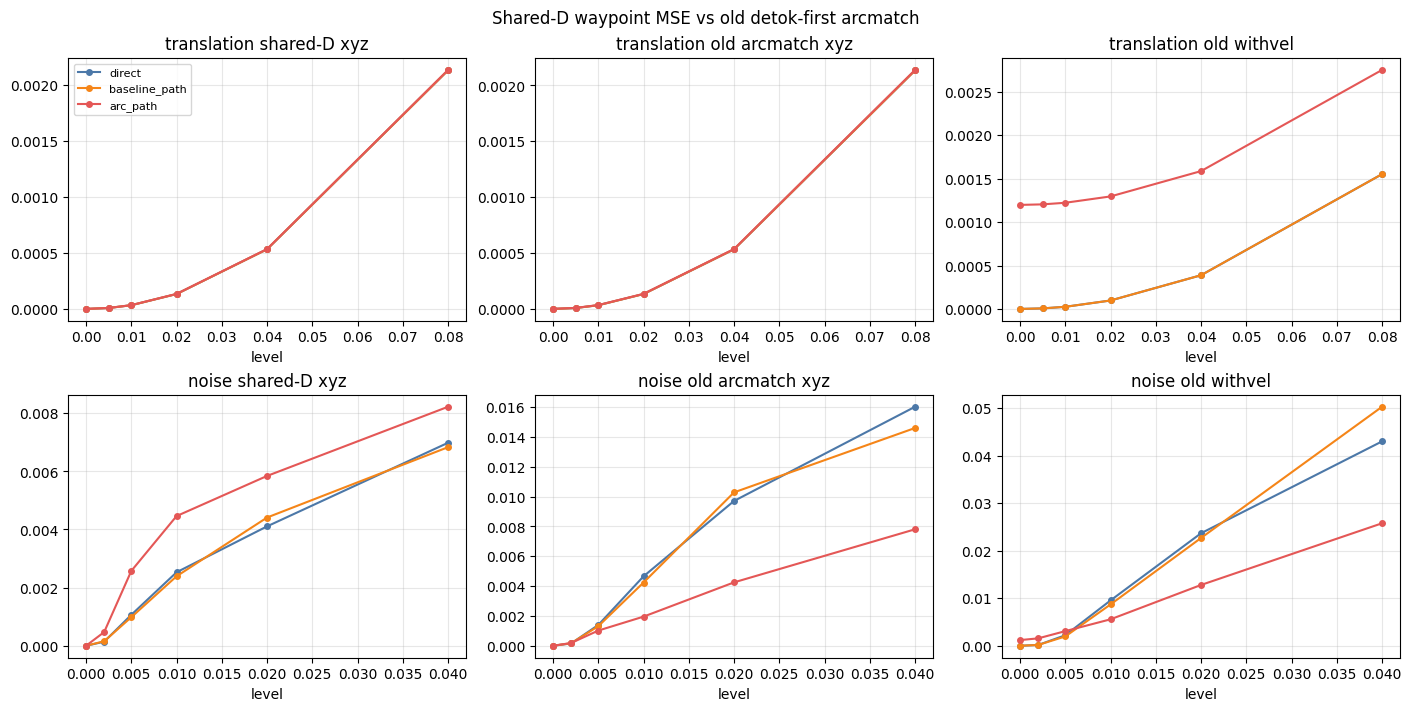


xyz_translation shared-D xyz arc/baseline:


,arc/base
level,
0.000,NaN
0.005,1.071554
0.010,1.024179
0.020,1.009190
0.040,1.003870
0.080,1.001754



xyz_noise shared-D xyz arc/baseline:


,arc/base
level,
0.000,NaN
0.002,3.034312
0.005,2.618352
0.010,1.865996
0.020,1.324298
0.040,1.203477


In [34]:
def _sd_curve(df: pd.DataFrame, sweep: str, metric: str) -> pd.DataFrame:
    sub = df[df["sweep"] == sweep]
    return (
        sub.groupby(["level", "mode"], as_index=False)[metric]
        .mean()
        .pivot(index="level", columns="mode", values=metric)
    )


fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
specs = [
    ("xyz_translation", "shared_d_xyz_mse", "translation shared-D xyz"),
    ("xyz_translation", "old_arcmatch_xyz_mse", "translation old arcmatch xyz"),
    ("xyz_translation", "old_arcmatch_withvel_paired_mse", "translation old withvel"),
    ("xyz_noise", "shared_d_xyz_mse", "noise shared-D xyz"),
    ("xyz_noise", "old_arcmatch_xyz_mse", "noise old arcmatch xyz"),
    ("xyz_noise", "old_arcmatch_withvel_paired_mse", "noise old withvel"),
]
for ax, (sweep, metric, title) in zip(axes.ravel(), specs):
    cur = _sd_curve(DF_SD, sweep, metric)
    for mode, color in (
        ("direct", "#4c78a8"),
        ("baseline_path", "#f58518"),
        ("arc_path", "#e45756"),
    ):
        if mode not in cur.columns:
            continue
        ax.plot(cur.index, cur[mode], color=color, marker="o", ms=4, label=mode)
    ax.set_title(title)
    ax.set_xlabel("level")
    ax.grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Shared-D waypoint MSE vs old detok-first arcmatch")
plt.show()

# arc/baseline ratios for shared-D (expect ~1 on translation)
for sweep in ("xyz_translation", "xyz_noise"):
    cur = _sd_curve(DF_SD, sweep, "shared_d_xyz_mse")
    ratio = cur["arc_path"] / cur["baseline_path"].replace(0, np.nan)
    print(f"\n{sweep} shared-D xyz arc/baseline:")
    display(ratio.to_frame("arc/base"))



Identity floor: shared-D vs old detok-first


,shared_d_xyz_mse,shared_span_m,pred_travel_m,L45_m,old_arcmatch_xyz_mse,old_arcmatch_withvel_paired_mse
mode,,,,,,
direct,0.000000e+00,0.276224,0.395554,0.395554,0.000000e+00,0.000000
baseline_path,0.000000e+00,0.276224,0.395554,0.395554,0.000000e+00,0.000000
arc_path,3.865911e-07,0.275540,0.276115,0.395554,8.875880e-07,0.001198


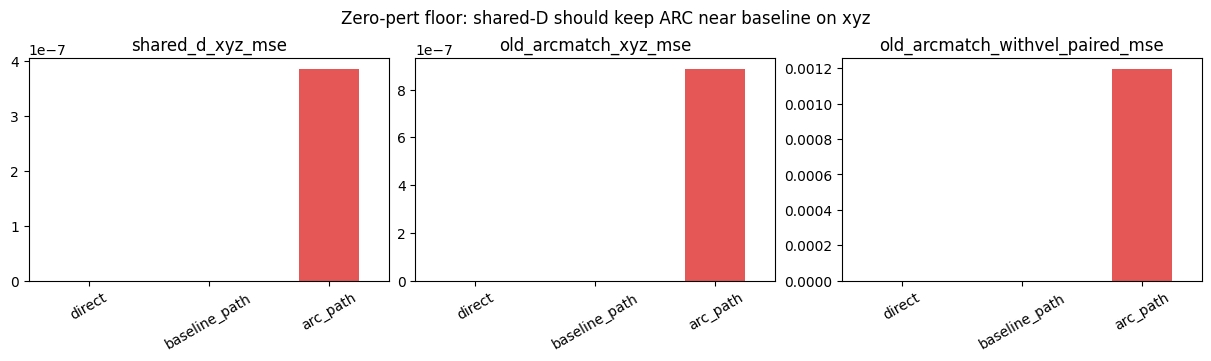

In [35]:
# Explicit floor contrast: identity perturbation
contrast = (
    DF_SD[(DF_SD["sweep"] == "xyz_translation") & (DF_SD["level"] == 0.0)]
    .groupby("mode", as_index=False)[
        [
            "shared_d_xyz_mse",
            "shared_span_m",
            "pred_travel_m",
            "L45_m",
            "old_arcmatch_xyz_mse",
            "old_arcmatch_withvel_paired_mse",
        ]
    ]
    .mean(numeric_only=True)
    .set_index("mode")
    .reindex(["direct", "baseline_path", "arc_path"])
)
print("Identity floor: shared-D vs old detok-first")
display(contrast)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
for ax, key in zip(
    axes,
    [
        "shared_d_xyz_mse",
        "old_arcmatch_xyz_mse",
        "old_arcmatch_withvel_paired_mse",
    ],
):
    contrast[key].plot(
        kind="bar", ax=ax, color=["#4c78a8", "#f58518", "#e45756"]
    )
    ax.set_title(key)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("Zero-pert floor: shared-D should keep ARC near baseline on xyz")
plt.show()



## Prep length before tokenize: T=45 (deinterp) vs T=100

Production deinterps baseline/GT to `arc_chunk_rows=45` because the loader
interpolates the raw window up to `chunk_length=100`, and arc length on that
interpolated path chord-cuts. Question for **shared-D** fairness: should we
prep at 45, keep both sides at 100, or detok ARC to 100 and also keep baseline
at 100?

Compares three preps:

| prep | GT / baseline | ARC pred geometry |
|------|---------------|-------------------|
| `T45_wp` | deinterp 45 | token waypoints (M) |
| `T100_wp` | keep 100 | token waypoints (M) |
| `T100_detok` | keep 100 | detok horizon 100 |

Shared-D formula unchanged: `shared = min(L_gt, D, L_pred)`.



In [ ]:
def prep_gt_base(chunk: np.ndarray, prep: str) -> np.ndarray:
    arr = np.asarray(chunk, dtype=np.float64)
    if prep.startswith("T45"):
        return deinterpolate_traj(arr, ARC_CHUNK_ROWS)
    return arr


def prep_arc_pred(chunk: np.ndarray, prep: str) -> np.ndarray:
    if prep.endswith("_detok"):
        return arc_pred_path(chunk)
    return arc_waypoint_polyline(chunk)


PREP_MODES = ("T45_wp", "T100_wp", "T100_detok")
PREP_SWEEPS = {
    "xyz_translation": [0.0, 0.01, 0.02, 0.04, 0.08],
    "xyz_noise": [0.0, 0.005, 0.01, 0.02, 0.04],
}
PREP_ROWS: list[dict] = []

for src_name, chunks in TRAJECTORIES.items():
    for sample_i, full in enumerate(chunks):
        full = np.asarray(full, dtype=np.float64)
        for prep in PREP_MODES:
            gt = prep_gt_base(full, prep)
            for sweep_name, levels in PREP_SWEEPS.items():
                for level in levels:
                    seed = abs(hash((src_name, sample_i, sweep_name, float(level), prep))) % (
                        2**32
                    )
                    rng = np.random.default_rng(seed)
                    if sweep_name == "xyz_translation":
                        pert_full = perturb_xyz_translation(full, level)
                        direct = perturb_xyz_translation(gt, level)
                    else:
                        pert_full = perturb_xyz_noise(full, level, rng)
                        direct = perturb_xyz_noise(
                            gt, level, np.random.default_rng(seed)
                        )
                    preds = {
                        "direct": direct,
                        "baseline_path": prep_gt_base(pert_full, prep),
                        "arc_path": prep_arc_pred(pert_full, prep),
                    }
                    for mode, pred in preds.items():
                        # score_shared_d always deinterps gt_full internally --
                        # override by scoring against gt already prepped:
                        spans = shared_spans(gt, pred, MIN_DISTANCE_UNIT)
                        if not np.all(np.isfinite(spans)) or np.any(spans <= 0):
                            continue
                        pw, _ = tokenize_span(pred, spans, ARCMATCH_POINTS, METRIC_DT)
                        gw, _ = tokenize_span(gt, spans, ARCMATCH_POINTS, METRIC_DT)
                        L = arm_travel(gt)
                        P = arm_travel(pred)
                        PREP_ROWS.append(
                            {
                                "source": src_name,
                                "sample": sample_i,
                                "prep": prep,
                                "sweep": sweep_name,
                                "level": float(level),
                                "mode": mode,
                                "shared_d_xyz_mse": mse(pw[None], gw[None], XYZ_COLS),
                                "shared_span_m": float(np.mean(spans)),
                                "Lgt_m": float(np.mean(L)),
                                "pred_travel_m": float(np.mean(P)),
                                "T_gt": len(gt),
                                "T_pred": len(pred),
                            }
                        )

DF_PREP = pd.DataFrame(PREP_ROWS)
print("DF_PREP", DF_PREP.shape)

# Travel: 100 vs 45 on same chunks
travel_cmp = []
for src_name, chunks in TRAJECTORIES.items():
    for sample_i, full in enumerate(chunks):
        L100 = float(np.mean(arm_travel(np.asarray(full, dtype=np.float64))))
        L45 = float(np.mean(arm_travel(to_gt(full))))
        travel_cmp.append(
            {
                "source": src_name,
                "sample": sample_i,
                "L100": L100,
                "L45": L45,
                "L100/L45": L100 / max(L45, 1e-12),
            }
        )
display(pd.DataFrame(travel_cmp))

floor_prep = (
    DF_PREP[(DF_PREP["sweep"] == "xyz_translation") & (DF_PREP["level"] == 0.0)]
    .groupby(["prep", "mode"], as_index=False)[
        ["shared_d_xyz_mse", "shared_span_m", "Lgt_m", "pred_travel_m"]
    ]
    .mean(numeric_only=True)
)
display(floor_prep)



In [ ]:
def _prep_curve(prep: str, sweep: str) -> pd.DataFrame:
    sub = DF_PREP[(DF_PREP["prep"] == prep) & (DF_PREP["sweep"] == sweep)]
    return (
        sub.groupby(["level", "mode"], as_index=False)["shared_d_xyz_mse"]
        .mean()
        .pivot(index="level", columns="mode", values="shared_d_xyz_mse")
    )


fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
for col, prep in enumerate(PREP_MODES):
    for row, sweep in enumerate(("xyz_translation", "xyz_noise")):
        ax = axes[row, col]
        cur = _prep_curve(prep, sweep)
        for mode, color in (
            ("direct", "#4c78a8"),
            ("baseline_path", "#f58518"),
            ("arc_path", "#e45756"),
        ):
            if mode in cur.columns:
                ax.plot(cur.index, cur[mode], color=color, marker="o", ms=3, label=mode)
        ax.set_title(f"{prep} / {sweep}")
        ax.set_xlabel("level")
        ax.grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=7)
fig.suptitle("Shared-D xyz MSE by prep: T45_wp vs T100_wp vs T100_detok")
plt.show()

summary_rows = []
for prep in PREP_MODES:
    tr = _prep_curve(prep, "xyz_translation")
    nz = _prep_curve(prep, "xyz_noise")
    r = tr.loc[[0.02, 0.04, 0.08], "arc_path"] / tr.loc[
        [0.02, 0.04, 0.08], "baseline_path"
    ].replace(0, np.nan)
    summary_rows.append(
        {
            "prep": prep,
            "transl_arc/base@0.04": float(
                tr.loc[0.04, "arc_path"] / max(float(tr.loc[0.04, "baseline_path"]), 1e-12)
            ),
            "transl_mean_|log(arc/base)|": float(np.mean(np.abs(np.log(r.clip(1e-12))))),
            "noise_arc/base@0.02": float(
                nz.loc[0.02, "arc_path"] / max(float(nz.loc[0.02, "baseline_path"]), 1e-12)
            ),
            "arc_floor": float(
                DF_PREP[
                    (DF_PREP["prep"] == prep)
                    & (DF_PREP["sweep"] == "xyz_translation")
                    & (DF_PREP["level"] == 0.0)
                    & (DF_PREP["mode"] == "arc_path")
                ]["shared_d_xyz_mse"].mean()
            ),
        }
    )
SUMMARY_PREP = pd.DataFrame(summary_rows)
display(SUMMARY_PREP)
print(
    "Recommendation: prefer the prep with transl_arc/base nearest 1 and "
    "noise_arc/base nearest 1 (usually T100_wp)."
)




## Readout

### Intended fair scorer (shared-D token space)

`shared_arm = min(L45_arm, D, pred_travel_arm)` then MSE over M waypoints
from `tokenize_span` on both pred and GT. Baseline uses the 45-row chunk;
ARC uses the **token waypoint polyline** (not horizon-100 detok).

### What was wrong with detok-first arcmatch

1. ARC was detokenized to T=100 before `match_spans`, so travel/timing differed
   from baseline T=45 even when shape matched.
2. `match_spans` was `min(pred, gt)` with **no explicit D**.
3. `withvel` used mean vel from time-index duration -- apples-to-oranges across
   codecs. Do not use withvel for baseline vs ARC scale comparisons.

### What shared-D fixes / still watch

- Pure XYZ translation: baseline and ARC `shared_d_xyz_mse` should overlay.
- Noise: ARC tokens still low-pass along arc length; shared-D removes detok
  timing bias but not codec smoothing. For noise fairness, perturb in token
  space or accept ARC under-reporting high-frequency noise.
- Per-arm mins keep left/right independent (same as `tokenize_span`).
- If `L45 < D`, ARC waypoints are resampled down to `L45` (not MSE over full D).
- Travel diagnostics (`pred_travel_m`, `travel_ratio`, `shared_span_m`) stay
  beside the MSE so stalls are visible.

### Prep T=45 vs T=100 (before shared-D tokenize)

**Verdict: prefer `T100_wp`** for fair baseline vs ARC shared-D scoring.

| Prep | Translation fairness | Noise fairness | Notes |
|------|----------------------|----------------|-------|
| `T45_wp` | arc/base ~ 0.99 | **biased** -- deinterp subsamples and strips high-freq length/noise from baseline | Matches production `arc_chunk_rows` / raw window |
| `T100_wp` | arc/base ~ 1.00 | **best** among the three | Matches tokenizer training input (`chunk_length=100`); ARC = token waypoints |
| `T100_detok` | arc/base ~ 1.00 | **worst** -- detok low-passes noise | Both at T=100 time-indexed, but ARC path still denoises |

Why 45 existed: loader interpolates raw ~45 to 100; measuring arc length on the
interpolated path chord-cuts, so the evaluator deinterps back before scoring.
That matters for **travel diagnostics on smooth raw windows**. It hurts
**noise fairness** when comparing to ARC, because subsample-45 is a low-pass
relative to the 100-pt chunk the tokenizer actually consumed.

Detok-to-100 for ARC + keep-baseline-100 does **not** fix noise bias -- detok
is the low-pass. Keep ARC in **waypoint / token space** (`T100_wp`).

Use `T45_wp` only when you must match the production evaluator's reported
travel units, not for baseline↔ARC scale comparisons.
### ARC detok rule

Detokenize ARC **only when** `L_gt < D`. Otherwise score ARC from token
waypoints over `shared ~= D` (same M as baseline tokenize-at-D). Detok exists
solely so a short baseline and ARC can be re-tokenized over the same shorter
distance with the same M.

